Calcoliamo la media delle lampade di calibrazione dello strumento Catherine trovate nell'archivio ESO

E' una lamp wave di Catherine ma binnata $1\times1$ anzichè $2\times1$ come vorrei io e non misura $2106\times2000$ come vorrei io.\
Ma è una lampada al ThAr? Perchè ho l'ashi della vista del braccio VIS di XSHOOTER.

In [4]:
import glob
import os
from pyraf import iraf

# 0. If you Windows operative system, be sure that in your input file_list.txt there is _ and not :
# also replace the middle point "·" with "_" on the files automatically dowloaded by the ESO archive into C or D Windows hard disks.

# 1. Load the necessary IRAF packages
iraf.noao()
iraf.imred()
iraf.ccdred()

# 2. Make sure to adjust the pattern to match your actual lamp file names
lamp_pattern = "XSHOO*.fits"
lamp_files = sorted(glob.glob(lamp_pattern))

if not lamp_files:
    raise FileNotFoundError(f"No files found with pattern: {lamp_pattern}")

# If the data comes from MEF (multi-extension) instruments like X-Shooter,
# specify the scientific extension for each file (e.g., bias.fits[1])
# bias_files = [f"{f}[1]" for f in bias_files]

input_list = "lamp_list_forWindows.txt"
with open(input_list, "w") as f:   #it's writing file names into the list automatically 
    for filename in lamp_files:
        f.write(f"{filename}\n")

# 3. Name of the output Master lamp file
output_master_lamp = "lamp.fits"

# Remove the previous output if it already exists
if os.path.exists(output_master_lamp):
    os.remove(output_master_lamp)

# 4. Run zerocombine using PyRAF
# Note: combine='median' or 'average' with reject='sigclip' or 'minmax'
iraf.zerocombine(
    input=f"@{input_list}",
    output=output_master_lamp,
    combine="average",
    reject="minmax",
    ccdtype="",   # Leave it empty to avoid filtering on ccdtype header, the default is "zero" but this fits header has different keywords
    process="no",  # Do not process the output (e.g., do not trim or scale)
    scale="none",  # Bias frames typically do not require scaling
    statsec="",  # Use the entire frame if empty
    #interactive="no",
)

print(f"Master lamp created successfully: {output_master_lamp}")

# 5. Cleanup (optional)
#if os.path.exists(input_list):
#    os.remove(input_list)

Master lamp created successfully: lamp.fits


Adesso dovrei dividere la lamp.fits con la task apall e identitificare le righe con la lista ashi con la task echelle identify.\
Dovrei tagliare la lamp in 14 fenditure come la stella ma le dimensioni della CCD e il binning non combaciano.

Filename: lamp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 4000)   float32   
Dati 2D trovati nell'HDU [0] (PRIMARY)
Range pixel effettivo: [1000.3, 65535.0]
Range visualizzato (1%-99%): [1010.0, 3908.7]


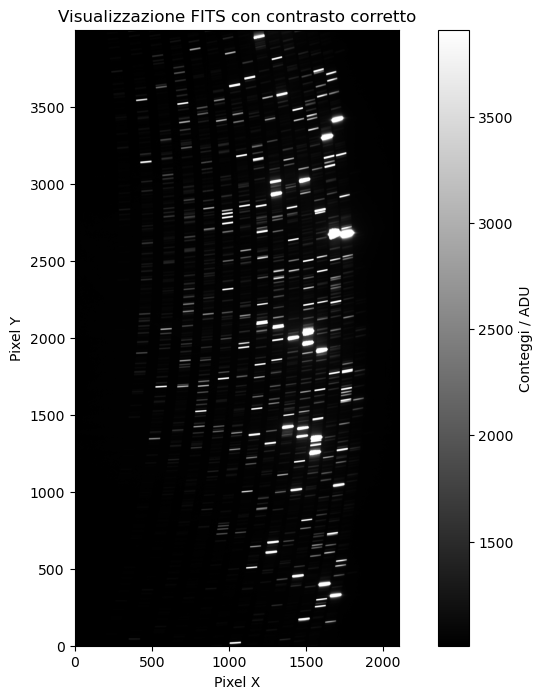

In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

file_path = "lamp.fits"

with fits.open(file_path) as hdul:
    hdul.info()  # Verifica quale HDU contiene ImageHDU o PrimaryHDU con dati

    # 1. Trova la prima estensione valida contenente un array 2D
    data = None
    for i, hdu in enumerate(hdul):
        if hdu.data is not None and getattr(hdu.data, "ndim", 0) == 2:
            data = hdu.data
            print(f"Dati 2D trovati nell'HDU [{i}] ({hdu.name})")
            break

if data is not None:
    # 2. Rimuovi eventuali NaN o infiniti per il calcolo del contrasto
    valid_data = data[np.isfinite(data)]

    # 3. Calcola i limiti di visualizzazione escludendo gli estremi (es. 1% e 99%)
    vmin, vmax = np.percentile(valid_data, [1.0, 99.0])

    print(
        f"Range pixel effettivo: [{np.min(valid_data):.1f}, {np.max(valid_data):.1f}]"
    )
    print(f"Range visualizzato (1%-99%): [{vmin:.1f}, {vmax:.1f}]")

    # 4. Mostra l'immagine con scala di grigi o viridis
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap="gray", origin="lower", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Conteggi / ADU")
    plt.title("Visualizzazione FITS con contrasto corretto")
    plt.xlabel("Pixel X")
    plt.ylabel("Pixel Y")
    plt.show()
else:
    print("Nessun array di dati 2D trovato nel file FITS.")

In [ ]:
#header of the lamp.fits
from astropy.io import fits

# Apri il file FITS
filename = "lamp.fits"
with fits.open(filename) as hdul:
    # Mostra la struttura del file (opzionale)
    hdul.info() 
    
    # Estrai l'header dell'estensione primaria (HDU 0)
    header = hdul[0].header 

# Stampa l'header in modo leggibile ed elegante
print(repr(header))

Filename: lamp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2106, 4000)   float32   
SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                 2106 / Axis length                                    
NAXIS2  =                 4000 / Axis length                                    
EXTEND  =                    T / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
IRAF-TLM= '2026-09-16T17:41:47' / Time of last modification                     
DATE    = '2026-09-16T17:41:49' / UT date when this file was written            
TELESCOP= 'Tel name not set'            / ESO Telescope Name                    
INSTRUME= 'XSHOOTER'                    